In [1]:
# from google.colab import runtime
# runtime.unassign()

In [1]:
!rm -rf sample_data/

In [2]:
# dependencies imports and checks

import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
try:
  import mlflow
except:
  %pip install mlflow

try:
  import torchvision
except:
  %pip install torchvision

import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms
from pathlib import Path
print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")

import glob

try:
  import torchinfo
except:
   %pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 136.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pwd

/content


In [4]:
!ls

data_setup.py  engine.py  model.py  utils.py


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')


In [8]:
# import os
# os.chdir("/content/drive/MyDrive/VLM_pipeline")
# print(os.getcwd())

In [5]:
# Modular imports
from data_setup import create_datasets, get_data
from engine import train
from model import ViT
from utils import (save_model, load_model, display_random_images_from_dataset,
                   set_seed, pred_and_plot_image, plot_loss_acc_curves,
                   plot_random_images_from_path, get_device,
                   walk_through_dir,
                   plot_confusion_matrix,
                   print_patched_image)

In [6]:
from torch.profiler import profile, ProfilerActivity, record_function

In [7]:
device = get_device()
device

'cuda'

In [8]:
get_data()

Did not find /content/data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [9]:
train_dir = Path('./data/pizza_steak_sushi/train')
test_dir = Path('./data/pizza_steak_sushi/test')

In [10]:
training_resolution = 224

vit_preprocess_transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((training_resolution,training_resolution))
])

In [11]:
vit_train_dataloader, vit_test_dataloader, vit_class_names, vit_class_to_idx = create_datasets(
                    train_dir = train_dir,
                    test_dir = test_dir,
                    train_transformations = vit_preprocess_transformations,
                    test_transformations= vit_preprocess_transformations,
                    NUM_WORKERS= 0,
                    BATCH_SIZE = 32,
                    PIN_MEMORY = False,
                    DROP_LAST= True)

In [14]:
set_seed(42)

ViT_model = ViT(patch_projection_size=768,
               patch_resolution=16,
               BATCH_SIZE=32,
               num_patches=196,
               in_channels=3,
               num_transformer_layers=12,
               dropout_rate=0,
               num_heads=12,
               MLP_size=3072,
               num_classes = len(vit_class_names))

In [13]:
# Vanilla ViT
from engine import train
from utils import get_device

device = get_device()
NUM_EPOCHS = 20

vit_optimizer = torch.optim.Adam(params = ViT_model.parameters(),
                                 lr=0.01,
                                  betas=(0.9,0.999),
                                  weight_decay=0)

vit_loss_fn = torch.nn.CrossEntropyLoss()

vit_train_results = train(model = ViT_model,
                train_dataloader= vit_train_dataloader,
                test_dataloader= vit_test_dataloader,
                optimizer= vit_optimizer,
                device = device,
                loss_fn= vit_loss_fn,
                epochs=NUM_EPOCHS
                )

  0%|          | 0/20 [00:00<?, ?it/s]

Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7 for training
Completed 4 batch out of 7 for training
Completed 5 batch out of 7 for training
Completed 6 batch out of 7 for training
Completed 7 batch out of 7 for training
Completed 1 batch out of 2 for testing
Completed 2 batch out of 2 for testing
Epoch: 1 | train_loss: 5.0201 | train_acc: 0.3393 | test_loss: 1.6084 | test_acc: 0.3906
Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7 for training
Completed 4 batch out of 7 for training
Completed 5 batch out of 7 for training
Completed 6 batch out of 7 for training
Completed 7 batch out of 7 for training
Completed 1 batch out of 2 for testing
Completed 2 batch out of 2 for testing
Epoch: 2 | train_loss: 3.3666 | train_acc: 0.3438 | test_loss: 2.2725 | test_acc: 0.3906
Completed 1 batch out of 7 for training
Completed 2 batch out of 7 for training
Completed 3 batch out of 7

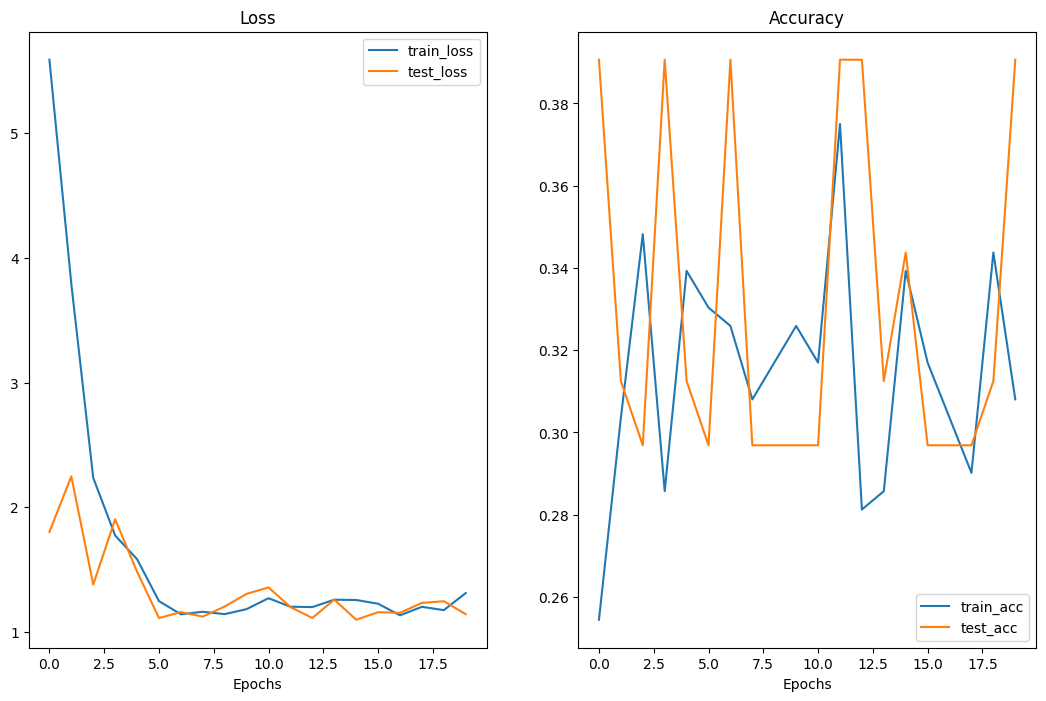

In [15]:
plot_loss_acc_curves(vit_train_results)


In [ ]:
# plot_confusion_matrix()

In [ ]:
# from datetime import datetime
# model_name = '5_epochs_'+ datetime.now().strftime('%Y_Y_%m_m_%d_d_%H:%M:%S')+'_VGG16MINI.pth'
# save_model(model=model,
#            target_dir='/content/models',
#            model_name=model_name)


In [ ]:
# !rm -rf /content/drive/MyDrive/VLM_pipeline/data/pizza_steak_sushi